# Exercsise Iason Kazazis
## Simple molecular dynamics

## Task 1(a): Relative position with periodic boundary conditions

In this cell, we implement the relative displacement vector  
$
\mathbf{r}_{ij}=\mathbf{r}_i-\mathbf{r}_j
$
under periodic boundary conditions.

Since the simulation box is periodic, the displacement between two particles must be computed using the **minimum image convention**. This means that, for each Cartesian component, we choose the shortest possible displacement inside the box of side length L.

The function `r_rel_pbc(ri, rj)` returns the shortest relative displacement vector between two particles and is used later in the computation of the Lennard--Jones potential and force.

In [41]:
import numpy as np

# Box length
L = 10.0

def r_rel_pbc(ri, rj, L=L):
    
    ri = np.asarray(ri, dtype=float)
    rj = np.asarray(rj, dtype=float)

    r_vec = ri - rj  

    for k in range(3):
        r_k = ri[k] - rj[k]
        if abs(r_k) > L / 2.0:
            r_vec[k] = -np.sign(r_k) * (L - abs(r_k))

    return r_vec


# simple tests

ri = np.array([9.0, 1.0, 1.0])
rj = np.array([1.0, 1.0, 1.0])
print("Test 1:", r_rel_pbc(ri, rj))   # -2,0 ,0

ri = np.array([1.0, 9.0, 1.0])
rj = np.array([9.0, 1.0, 1.0])
print("Test 2:", r_rel_pbc(ri, rj))   #2,-2 0

ri = np.array([2.0, 3.0, 4.0])
rj = np.array([1.0, 1.0, 1.0])   # 1,2,3
print("Test 3:", r_rel_pbc(ri, rj))   

Test 1: [-2.  0.  0.]
Test 2: [ 2. -2.  0.]
Test 3: [1. 2. 3.]


## Task 1(b): Leapfrog integration step

In this cell, we implement one step of the **Leapfrog integration scheme** with periodic boundary conditions.

The positions are defined at integer time steps, while the velocities are defined at half-integer time steps. For each time step, the algorithm performs the following operations:

1. Wrap the current particle positions back into the simulation box.
2. Compute the total force acting on each particle.
3. Update the half-step velocities.
4. Estimate the velocities at integer time using the average of the two neighbouring half-step velocities.
5. Update the particle positions.
6. Apply periodic boundary conditions again.

This function provides the basic time-evolution step of the molecular dynamics simulation.

In [42]:
def stepLeapfrog(r_current, v_half_previous):

    # put current positions back
    r_current_pbc = r_current % L

    # compute forces at time t
    F = total_force(r_current_pbc)

    # acceleration m=1
    a_current = F

    # leapfrog velocity update v(t + dt/2) = v(t - dt/2) + a(t) * dt
    v_half_next = v_half_previous + a_current * dt

    # estimate velocity at integer time t: v(t) = [v(t-dt/2) + v(t+dt/2)] / 2
    v_current = 0.5 * (v_half_previous + v_half_next)

    # leapfrog position update: r(t + dt) = r(t) + v(t + dt/2) * dt
    r_next = r_current_pbc + v_half_next * dt

    # apply periodic bcd 
    r_next = r_next % L

    return r_current_pbc, v_current, r_next, v_half_next, F

## Quick test of the Leapfrog step

In this cell, we test the function `stepLeapfrog(...)` in a simple case where the total force is set to zero for all particles.

This test is useful to verify that:

- periodic boundary conditions are applied correctly,
- the half-step velocities remain unchanged when the force is zero,
- the new particle positions are updated correctly according to the Leapfrog rule.

Since no forces act on the particles in this test, the motion should reduce to uniform linear motion with periodic wrapping.

In [43]:
# quick test for step leapfrog

N = 4
L = 10.0
dt = 1e-3

# force function just for testing the shape/output
def total_force(r_current):
    return np.zeros_like(r_current)

r_current = np.array([
    [9.9, 1.0, 1.0],
    [0.2, 2.0, 2.0],
    [5.0, 5.0, 5.0],
    [10.1, -0.1, 3.0]
], dtype=float)

v_half_previous = np.array([
    [1.0, 0.0, 0.0],
    [-1.0, 0.0, 0.0],
    [0.0, 0.5, 0.0],
    [0.0, 0.0, -0.5]
], dtype=float)

r_now, v_now, r_next, v_half_next, F = stepLeapfrog(r_current, v_half_previous)

print("r_now =\n", r_now)
print("v_now =\n", v_now)
print("r_next =\n", r_next)
print("v_half_next =\n", v_half_next)
print("F =\n", F)

r_now =
 [[9.9 1.  1. ]
 [0.2 2.  2. ]
 [5.  5.  5. ]
 [0.1 9.9 3. ]]
v_now =
 [[ 1.   0.   0. ]
 [-1.   0.   0. ]
 [ 0.   0.5  0. ]
 [ 0.   0.  -0.5]]
r_next =
 [[9.901  1.     1.    ]
 [0.199  2.     2.    ]
 [5.     5.0005 5.    ]
 [0.1    9.9    2.9995]]
v_half_next =
 [[ 1.   0.   0. ]
 [-1.   0.   0. ]
 [ 0.   0.5  0. ]
 [ 0.   0.  -0.5]]
F =
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


## Task 1(c): Velocity at integer time

In the Leapfrog scheme, particle velocities are naturally defined at half-integer time steps, i.e.\ at
$
t-\frac{\Delta t}{2}
\quad \text{and} \quad
t+\frac{\Delta t}{2}.
$

To estimate the velocity at the integer time \(t\), we take the average of the two neighbouring half-step velocities:
$
\mathbf{v}(t)=\frac{\mathbf{v}\left(t-\frac{\Delta t}{2}\right)+\mathbf{v}\left(t+\frac{\Delta t}{2}\right)}{2}.
$

The function `estimate_v_current(...)` implements this formula. This estimate is later used in the computation of the kinetic energy and of the total energy of the system.

In [44]:
def estimate_v_current(v_half_previous, v_half_next):

    v_current = 0.5 * (v_half_previous + v_half_next)
    return v_current


## Task 1(d): Lennard--Jones potential and force with cut-off radius

In this cell, we implement the Lennard--Jones pair potential, the corresponding pair force, and the total force acting on each particle.

The Lennard--Jones potential is given by
$
V(r)=4\left(r^{-12}-r^{-6}\right),
$
and the corresponding force is obtained from its gradient. In the implementation, the relative displacement between particles is computed using the periodic-boundary-condition function from Task 1(a).

A cut-off radius $r_c=2.5$ is introduced in order to reduce the computational cost. Therefore, if the distance between two particles satisfies $r \ge r_c$, both the pair potential and the pair force are set equal to zero. This avoids unnecessary calculations for particle pairs whose interaction is negligible.

The function `total_force(r_current)` computes the total force acting on each particle by summing over all distinct pairs and using Newton's third law in order to avoid double counting.

The quick test confirms the expected behaviour:
- for a particle pair with distance $r=1$, the potential is $V(1)=0$,
- the corresponding force is non-zero and repulsive,
- for a particle pair with distance larger than the cut-off radius, both the potential and the force vanish.

In [45]:
def stepLeapfrog(r_current, v_half_previous):
    
    # particles inside the box
    r_current_pbc = r_current % L

    # forces at time t
    F = total_force(r_current_pbc)

    # m = 1
    a_current = F

    # leapfrog velocity update: from t-dt/2 to t+dt/2
    v_half_next = v_half_previous + a_current * dt

    # tsk 1(c): estimate velocity at integer time t
    v_current = estimate_v_current(v_half_previous, v_half_next)

    # leapfrog position update: from t to t+dt
    r_next = r_current_pbc + v_half_next * dt

    # restore particles into the box according to PBC
    r_next = r_next % L

    return r_current_pbc, v_current, r_next, v_half_next, F

In [46]:
import numpy as np
import math

N = 40
L = 10.0
rc = 2.5
T = 10000
dt = 1e-3

In [47]:
def potential(ri, rj):
    
    #Lennard-Jones potential   V(r) = 4 * (r^-12 - r^-6)
    
    r_vec = r_rel_pbc(ri, rj)
    r2 = np.dot(r_vec, r_vec)

    if r2 == 0 or r2 >= rc**2:
        return 0.0

    r2_inv = 1.0 / r2
    r6_inv = r2_inv ** 3

    return 4.0 * (r6_inv**2 - r6_inv)


def force(ri, rj):
    
    r_vec = r_rel_pbc(ri, rj)
    r2 = np.dot(r_vec, r_vec)

    if r2 == 0 or r2 >= rc**2:
        return np.zeros(3)

    r2_inv = 1.0 / r2
    r6_inv = r2_inv ** 3

    # F = 24 * (2*r^-14 - r^-8) * r_vec
    prefactor = 24.0 * r2_inv * (2.0 * r6_inv**2 - r6_inv)

    return prefactor * r_vec


def total_force(r_current):
    
    F = np.zeros((N, 3))

    for i in range(N):
        for j in range(i + 1, N):
            f_ij = force(r_current[i], r_current[j])
            F[i] += f_ij
            F[j] -= f_ij

    return F

In [48]:
ri = np.array([1.0, 1.0, 1.0])
rj_close = np.array([2.0, 1.0, 1.0])   # distance = 1 < rc
rj_far   = np.array([5.0, 1.0, 1.0])   # distance = 4 > rc

print("potential close =", potential(ri, rj_close))
print("force close =", force(ri, rj_close))

print("potential far =", potential(ri, rj_far))
print("force far =", force(ri, rj_far))

r_test = np.random.uniform(0, L, size=(N, 3))
F_test = total_force(r_test)
print("total_force shape =", F_test.shape)
print(F_test[:3])

potential close = 0.0
force close = [-24.   0.   0.]
potential far = 0.0
force far = [0. 0. 0.]
total_force shape = (40, 3)
[[-0.08053321  0.22444233 -0.23388764]
 [ 0.16658463  0.34450118 -0.06154632]
 [-2.24142821  0.22247038 -0.49545199]]


## Task 1(e): Estimate of the maximum number of particles

In this cell, we estimate the maximum number of particles that can fit inside the cubic simulation box.

Following the approximation suggested in the exercise, we interpret $r_c/2$ as an effective particle radius. Therefore, the corresponding effective particle diameter is $r_c$. Under a simple-cubic packing assumption, the number of particles that can fit along one side of the box is approximately
$
\left\lfloor \frac{L}{r_c} \right\rfloor.
$

Hence, the maximum number of particles that fit in the full three-dimensional box is
$
N_{\max}=
\left\lfloor \frac{L}{r_c} \right\rfloor^3.
$

For the present values $L=10$ and $r_c=2.5$, we obtain
$
N_{\max}=4^3=64.
$

This gives a rough geometric estimate of the largest number of particles that can be placed in the box under the given approximation.

In [49]:

n_side = math.floor(L / rc)
N_max = n_side ** 3

print("Task 1(e)")
print(f"Particles per side = floor(L/rc) = floor({L}/{rc}) = {n_side}")
print(f"N_max = floor(L/rc)^3 = {N_max}")

Task 1(e)
Particles per side = floor(L/rc) = floor(10.0/2.5) = 4
N_max = floor(L/rc)^3 = 64


## Task 1(f): Initial conditions

In this cell, we construct the initial conditions of the molecular dynamics simulation.

To avoid large unphysical overlaps between particles at the beginning of the simulation, the initial particle positions are placed on a regular cubic lattice inside the simulation box. For $N=40$, the smallest cubic grid that can contain all particles has
$
n_{\text{side}}=\lceil N^{1/3}\rceil=4
$
lattice points per side, which gives a lattice spacing
$
\text{spacing}=\frac{L}{n_{\text{side}}}=\frac{10}{4}=2.5.
$

The initial velocities are sampled from a three-dimensional Gaussian distribution. In order to eliminate any global drift of the system, the mean velocity is subtracted from all particles,so that the center-of-mass velocity is zero up to machine precision.

Finally, the initial half-step velocities required by the Leapfrog method are computed from the initial velocities and the initial forces.

In [50]:
# Task 1(f): initial conditions, positions on a regular cubic lattice, velocities from a 3D gaussian distribution

np.random.seed(42)

energy_arr = np.zeros(T)

# positions: regular cubic lattice
n_side = int(np.ceil(N ** (1/3)))   # number of lattice points per side
spacing = L / n_side                # lattice spacing

coords_1d = (np.arange(n_side) + 0.5) * spacing

lattice_points = []
for x in coords_1d:
    for y in coords_1d:
        for z in coords_1d:
            lattice_points.append([x, y, z])

r_current = np.array(lattice_points[:N], dtype=float)

# velocities: Gaussian distribution in 3D
v_current = np.random.normal(loc=0.0, scale=1.0, size=(N, 3))

# remove center of mass drift
v_current -= np.mean(v_current, axis=0)

# initialize half step velocities
F_initial = total_force(r_current % L)
v_half = v_current - 0.5 * F_initial * dt

print("r_current shape =", r_current.shape)
print("v_current shape =", v_current.shape)
print("Center-of-mass velocity =", np.mean(v_current, axis=0))
print("Lattice spacing =", spacing)

r_current shape = (40, 3)
v_current shape = (40, 3)
Center-of-mass velocity = [-5.55111512e-17 -1.66533454e-17  4.16333634e-17]
Lattice spacing = 2.5


## Task 2(a): Total energy as a function of time

In this cell, we compute the total energy of the molecular dynamics system during the full simulation.

The total energy is defined as
$
E(t)=E_{\mathrm{kin}}(t)+E_{\mathrm{pot}}(t),
$
where the kinetic energy is
$
E_{\mathrm{kin}}(t)=\frac{1}{2}\sum_{i=1}^{N} |\mathbf{v}_i(t)|^2
$
and the potential energy is obtained by summing the Lennard--Jones interaction over all distinct particle pairs.

After defining the total-energy function, we initialize the system again using the same lattice positions and Gaussian-distributed velocities as in Task 1(f). The system is then evolved in time using the Leapfrog scheme, and the total energy is stored at every time step.

Finally, we plot the total energy as a function of time and print basic numerical quantities such as the mean energy, the standard deviation, and the maximum drift from the initial value. This allows us to assess whether the numerical integration approximately conserves the total energy.

In [51]:
import numpy as np
import math
import matplotlib.pyplot as plt

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

In [52]:
def energy(r_current, v_current):
    
    #Total energy of the system: E = E_kin + E_pot with m = 1 
    
    # kinetic energy
    E_kin = 0.5 * np.sum(v_current**2)

    # potential energy 
    E_pot = 0.0
    for i in range(N):
        for j in range(i + 1, N):
            E_pot += potential(r_current[i], r_current[j])

    return E_kin + E_pot

In [53]:


np.random.seed(42)

energy_arr = np.zeros(T)

# initial positions 
n_side = int(np.ceil(N ** (1/3)))
spacing = L / n_side
coords_1d = (np.arange(n_side) + 0.5) * spacing

lattice_points = []
for x in coords_1d:
    for y in coords_1d:
        for z in coords_1d:
            lattice_points.append([x, y, z])

r_current = np.array(lattice_points[:N], dtype=float)

# initial velocities (gaussian)
v_current = np.random.normal(loc=0.0, scale=1.0, size=(N, 3))

# remove com drift
v_current -= np.mean(v_current, axis=0)

# initialize velocities
F_initial = total_force(r_current % L)
v_half = v_current - 0.5 * F_initial * dt

# time evolution
for t in range(T):
    r_current, v_current, r_next, v_half, F_ij = stepLeapfrog(r_current, v_half)
    energy_arr[t] = energy(r_current, v_current)
    r_current = r_next

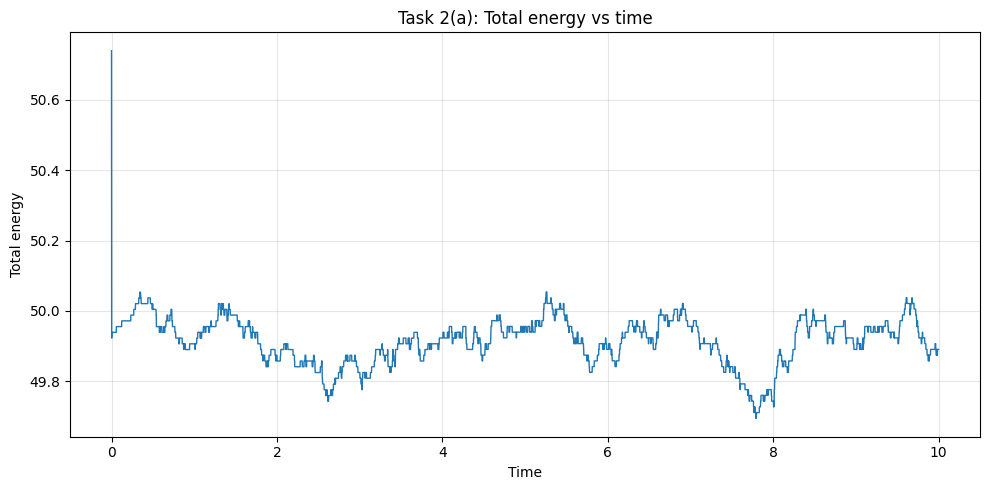

Initial energy  E(0)    = 50.739812561912984
Mean energy     <E>     = 49.91504247882826
Std(E)                  = 0.06531252321388421
Max |E(t)-E(0)|         = 1.0451367023654825
Relative max drift      = 0.02059796143492255


In [54]:
time_arr = np.arange(T) * dt

plt.figure(figsize=(10, 5))
plt.plot(time_arr, energy_arr, linewidth=1)
plt.xlabel("Time")
plt.ylabel("Total energy")
plt.title("Task 2(a): Total energy vs time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Initial energy  E(0)    =", energy_arr[0])
print("Mean energy     <E>     =", np.mean(energy_arr))
print("Std(E)                  =", np.std(energy_arr))
print("Max |E(t)-E(0)|         =", np.max(np.abs(energy_arr - energy_arr[0])))
print("Relative max drift      =", np.max(np.abs(energy_arr - energy_arr[0])) / abs(energy_arr[0]))

## Task 2(b): Energy fluctuations

In this cell, we analyse the fluctuations of the total energy around its mean value.

We define the absolute energy fluctuation as
$
\Delta E(t)=E(t)-\langle E\rangle,
$
where $\langle E\rangle$ is the average total energy over the full simulation. We also define the relative fluctuation as
$
\frac{E(t)-\langle E\rangle}{|\langle E\rangle|}.
$

These quantities provide a clearer view of the deviations from exact energy conservation than the total-energy plot alone. After computing both the absolute and relative fluctuations, we plot them as functions of time.

Finally, we print the mean fluctuation, its standard deviation, and the maximum absolute fluctuation. Since the fluctuation is defined relative to the mean energy, its average should be approximately zero, up to numerical round-off errors.

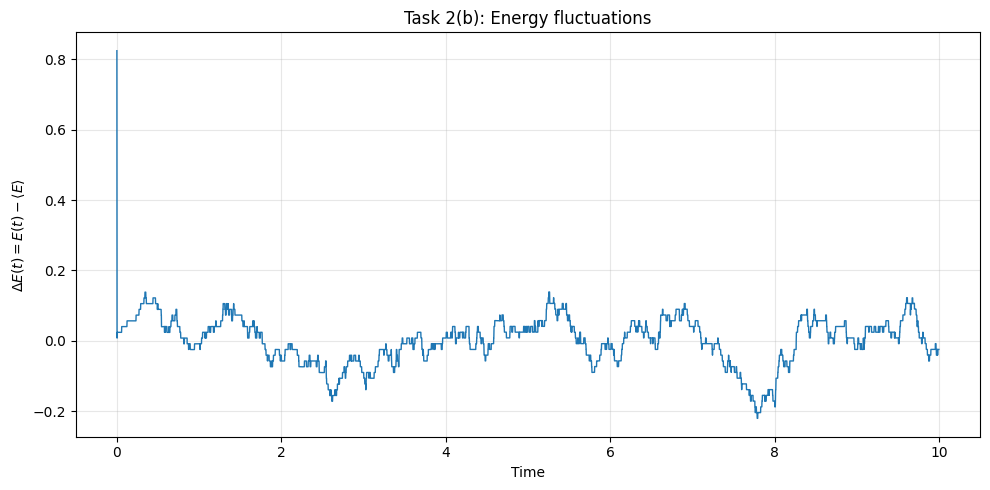

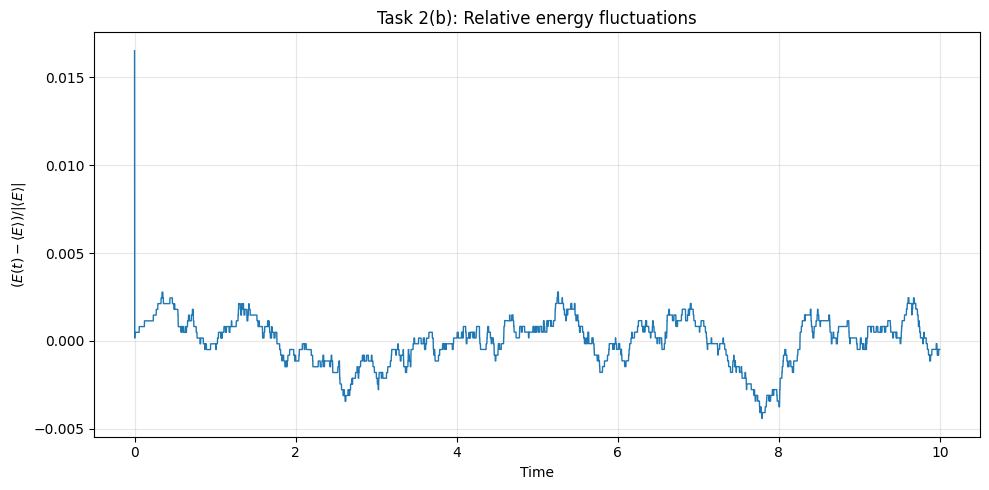

Mean fluctuation = -2.3639756818738533e-15
Std fluctuation  = 0.06531252321388421
Max |fluctuation| = 0.8247700830847222


In [55]:
delta_E = energy_arr - np.mean(energy_arr)
relative_delta_E = delta_E / abs(np.mean(energy_arr))

plt.figure(figsize=(10, 5))
plt.plot(time_arr, delta_E, linewidth=1)
plt.xlabel("Time")
plt.ylabel(r"$\Delta E(t) = E(t) - \langle E \rangle$")
plt.title("Task 2(b): Energy fluctuations")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(time_arr, relative_delta_E, linewidth=1)
plt.xlabel("Time")
plt.ylabel(r"$(E(t)-\langle E\rangle)/|\langle E\rangle|$")
plt.title("Task 2(b): Relative energy fluctuations")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean fluctuation =", np.mean(delta_E))
print("Std fluctuation  =", np.std(delta_E))
print("Max |fluctuation| =", np.max(np.abs(delta_E)))

## Task 3: Influence of the time-step size

In this cell, we study the influence of the time step $\Delta t$ on the numerical behaviour of the molecular dynamics simulation.

For each selected value of $\Delta t$, the system is re-initialised with the same initial positions and velocities, so that the comparison remains fair. The simulation is then run over the same total physical time interval, and the total energy is recorded throughout the trajectory.

After each run, we compute the absolute energy fluctuation
$
\Delta E(t)=E(t)-\langle E\rangle
$
and the relative fluctuation
$
\frac{E(t)-\langle E\rangle}{|\langle E\rangle|}.
$

We then compare these quantities for several values of $\Delta t$ by plotting the corresponding fluctuation curves and by printing summary statistics such as the standard deviation and the maximum absolute fluctuation.

This allows us to evaluate how the choice of time step affects the accuracy and stability of the Leapfrog integration scheme.

In [56]:
def run_md_for_dt(dt_value, total_time=10.0, seed=42):
    
    steps = int(total_time / dt_value)

    # same initial conditions for every dt
    np.random.seed(seed)

    n_side = int(np.ceil(N ** (1/3)))
    spacing = L / n_side
    coords_1d = (np.arange(n_side) + 0.5) * spacing

    lattice_points = []
    for x in coords_1d:
        for y in coords_1d:
            for z in coords_1d:
                lattice_points.append([x, y, z])

    r_current = np.array(lattice_points[:N], dtype=float)

    v_current = np.random.normal(loc=0.0, scale=1.0, size=(N, 3))

    
    v_current -= np.mean(v_current, axis=0)

    F_initial = total_force(r_current % L)
    v_half = v_current - 0.5 * F_initial * dt_value

    energy_arr = np.zeros(steps)

    for t in range(steps):
#local leapfrog
        r_current_pbc = r_current % L
        F = total_force(r_current_pbc)
        a_current = F

        v_half_next = v_half + a_current * dt_value
        v_current = 0.5 * (v_half + v_half_next)
        r_next = (r_current_pbc + v_half_next * dt_value) % L

        energy_arr[t] = energy(r_current_pbc, v_current)

        r_current = r_next
        v_half = v_half_next

    time_arr = np.arange(steps) * dt_value
    delta_E = energy_arr - np.mean(energy_arr)
    rel_delta_E = delta_E / abs(np.mean(energy_arr))

    return time_arr, energy_arr, delta_E, rel_delta_E

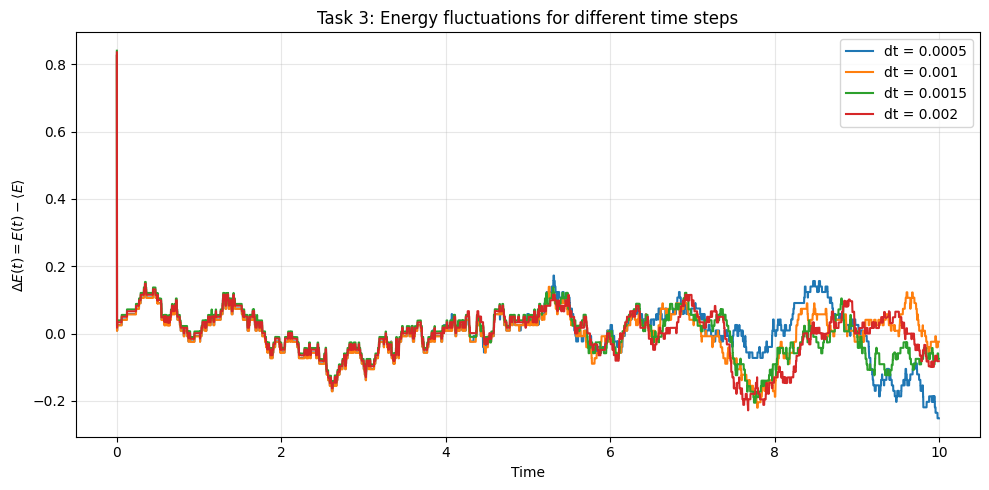

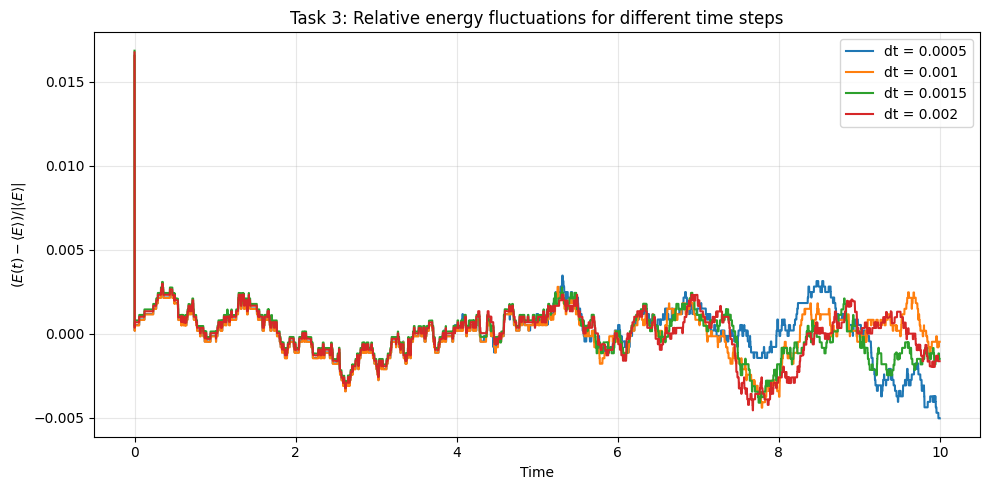

Summary:
dt = 0.0005
  std(ΔE)           = 7.589607e-02
  max |ΔE|          = 8.254934e-01
  std(relative ΔE)  = 1.520527e-03
  max |relative ΔE| = 1.653821e-02

dt = 0.001
  std(ΔE)           = 6.531252e-02
  max |ΔE|          = 8.247701e-01
  std(relative ΔE)  = 1.308474e-03
  max |relative ΔE| = 1.652348e-02

dt = 0.0015
  std(ΔE)           = 6.794589e-02
  max |ΔE|          = 8.401577e-01
  std(relative ΔE)  = 1.361651e-03
  max |relative ΔE| = 1.683694e-02

dt = 0.002
  std(ΔE)           = 7.129667e-02
  max |ΔE|          = 8.352170e-01
  std(relative ΔE)  = 1.428659e-03
  max |relative ΔE| = 1.673627e-02



In [57]:
# Task 3 compare different time steps
dt_values = [5e-4, 1e-3, 1.5e-3, 2e-3]
total_time = 10.0   

results = {}

for dt_val in dt_values:
    time_arr, energy_arr, delta_E, rel_delta_E = run_md_for_dt(dt_val, total_time=total_time, seed=42)
    results[dt_val] = {
        "time": time_arr,
        "energy": energy_arr,
        "delta_E": delta_E,
        "rel_delta_E": rel_delta_E,
        "std_delta_E": np.std(delta_E),
        "max_abs_delta_E": np.max(np.abs(delta_E)),
        "std_rel_delta_E": np.std(rel_delta_E),
        "max_abs_rel_delta_E": np.max(np.abs(rel_delta_E)),
    }

# absolute fluctuations
plt.figure(figsize=(10, 5))
for dt_val in dt_values:
    plt.plot(results[dt_val]["time"], results[dt_val]["delta_E"], label=f"dt = {dt_val}")
plt.xlabel("Time")
plt.ylabel(r"$\Delta E(t)=E(t)-\langle E\rangle$")
plt.title("Task 3: Energy fluctuations for different time steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# relative fluctuations
plt.figure(figsize=(10, 5))
for dt_val in dt_values:
    plt.plot(results[dt_val]["time"], results[dt_val]["rel_delta_E"], label=f"dt = {dt_val}")
plt.xlabel("Time")
plt.ylabel(r"$(E(t)-\langle E\rangle)/|\langle E\rangle|$")
plt.title("Task 3: Relative energy fluctuations for different time steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Summary:")
for dt_val in dt_values:
    print(f"dt = {dt_val}")
    print(f"  std(ΔE)           = {results[dt_val]['std_delta_E']:.6e}")
    print(f"  max |ΔE|          = {results[dt_val]['max_abs_delta_E']:.6e}")
    print(f"  std(relative ΔE)  = {results[dt_val]['std_rel_delta_E']:.6e}")
    print(f"  max |relative ΔE| = {results[dt_val]['max_abs_rel_delta_E']:.6e}")
    print()

## Visualisation of the simulation

In this part of the assignment, the simulation data are exported in a ParaView-compatible VTK format. For this purpose, a custom writer class (`CleanVTKWriter`) is used to generate `.vtu` snapshots containing the particle coordinates together with additional point data such as velocities, forces, radii, and scalar values for colouring.

The method `snapshot(...)` writes one simulation frame at a given time step, while the method `writePVD(...)` groups all snapshots into a single `.pvd` collection file. This allows the full time evolution of the system to be loaded and animated directly in ParaView.

After exporting the data, the particle positions can be visualised with the `Glyph` filter using spheres, while the interaction forces can be displayed with arrows. In this way, the visualisation provides an intuitive representation of both the particle motion and the instantaneous force field during the molecular dynamics evolution.


In [58]:
import os
import shutil
import numpy as np
import xml.dom.minidom

In [59]:
class CleanVTKWriter:
    def __init__(self):
        self.fileNames = []

    def coords_to_string(self, x, y, z):
        s = []
        for i in range(len(x)):
            s.append(f"{float(x[i])} {float(y[i])} {float(z[i])}")
        return " ".join(s)

    def array_to_string(self, a):
        return " ".join(str(float(v)) for v in a)

    def int_array_to_string(self, a):
        return " ".join(str(int(v)) for v in a)

    def snapshot(
        self,
        fileName,
        x, y, z,
        x_vel=None, y_vel=None, z_vel=None,
        x_force=None, y_force=None, z_force=None,
        radii=None,
        colors=None
    ):
        if x_vel is None: x_vel = []
        if y_vel is None: y_vel = []
        if z_vel is None: z_vel = []
        if x_force is None: x_force = []
        if y_force is None: y_force = []
        if z_force is None: z_force = []
        if radii is None: radii = []
        if colors is None: colors = []

        n = len(x)

        doc = xml.dom.minidom.Document()

        root = doc.createElement("VTKFile")
        root.setAttribute("type", "UnstructuredGrid")
        root.setAttribute("version", "0.1")
        root.setAttribute("byte_order", "LittleEndian")
        doc.appendChild(root)

        ug = doc.createElement("UnstructuredGrid")
        root.appendChild(ug)

        piece = doc.createElement("Piece")
        piece.setAttribute("NumberOfPoints", str(n))
        piece.setAttribute("NumberOfCells", str(n))
        ug.appendChild(piece)

        points = doc.createElement("Points")
        piece.appendChild(points)

        point_coords = doc.createElement("DataArray")
        point_coords.setAttribute("type", "Float32")
        point_coords.setAttribute("format", "ascii")
        point_coords.setAttribute("NumberOfComponents", "3")
        point_coords.appendChild(doc.createTextNode(self.coords_to_string(x, y, z)))
        points.appendChild(point_coords)

        cells = doc.createElement("Cells")
        piece.appendChild(cells)

        connectivity = doc.createElement("DataArray")
        connectivity.setAttribute("type", "Int32")
        connectivity.setAttribute("Name", "connectivity")
        connectivity.setAttribute("format", "ascii")
        connectivity.appendChild(doc.createTextNode(self.int_array_to_string(range(n))))
        cells.appendChild(connectivity)

        offsets = doc.createElement("DataArray")
        offsets.setAttribute("type", "Int32")
        offsets.setAttribute("Name", "offsets")
        offsets.setAttribute("format", "ascii")
        offsets.appendChild(doc.createTextNode(self.int_array_to_string(range(1, n + 1))))
        cells.appendChild(offsets)

        types = doc.createElement("DataArray")
        types.setAttribute("type", "UInt8")
        types.setAttribute("Name", "types")
        types.setAttribute("format", "ascii")
        types.appendChild(doc.createTextNode(" ".join(["1"] * n)))   # VTK_VERTEX = 1
        cells.appendChild(types)

        point_data = doc.createElement("PointData")
        piece.appendChild(point_data)

        pts_arr = doc.createElement("DataArray")
        pts_arr.setAttribute("Name", "Points")
        pts_arr.setAttribute("NumberOfComponents", "3")
        pts_arr.setAttribute("type", "Float32")
        pts_arr.setAttribute("format", "ascii")
        pts_arr.appendChild(doc.createTextNode(self.coords_to_string(x, y, z)))
        point_data.appendChild(pts_arr)

        if len(x_vel) > 0:
            vel_arr = doc.createElement("DataArray")
            vel_arr.setAttribute("Name", "Velocities")
            vel_arr.setAttribute("NumberOfComponents", "3")
            vel_arr.setAttribute("type", "Float32")
            vel_arr.setAttribute("format", "ascii")
            vel_arr.appendChild(doc.createTextNode(self.coords_to_string(x_vel, y_vel, z_vel)))
            point_data.appendChild(vel_arr)

        if len(x_force) > 0:
            force_arr = doc.createElement("DataArray")
            force_arr.setAttribute("Name", "Forces")
            force_arr.setAttribute("NumberOfComponents", "3")
            force_arr.setAttribute("type", "Float32")
            force_arr.setAttribute("format", "ascii")
            force_arr.appendChild(doc.createTextNode(self.coords_to_string(x_force, y_force, z_force)))
            point_data.appendChild(force_arr)

        if len(radii) > 0:
            radii_arr = doc.createElement("DataArray")
            radii_arr.setAttribute("Name", "radii")
            radii_arr.setAttribute("type", "Float32")
            radii_arr.setAttribute("format", "ascii")
            radii_arr.appendChild(doc.createTextNode(self.array_to_string(radii)))
            point_data.appendChild(radii_arr)

        if len(colors) > 0:
            color_arr = doc.createElement("DataArray")
            color_arr.setAttribute("Name", "colors")
            color_arr.setAttribute("type", "Float32")
            color_arr.setAttribute("format", "ascii")
            color_arr.appendChild(doc.createTextNode(self.array_to_string(colors)))
            point_data.appendChild(color_arr)

        cell_data = doc.createElement("CellData")
        piece.appendChild(cell_data)

        with open(fileName, "w") as f:
            doc.writexml(f, newl="\n")

        self.fileNames.append(fileName)

    def writePVD(self, fileName):
        doc = xml.dom.minidom.Document()

        root = doc.createElement("VTKFile")
        root.setAttribute("type", "Collection")
        root.setAttribute("version", "0.1")
        root.setAttribute("byte_order", "LittleEndian")
        doc.appendChild(root)

        collection = doc.createElement("Collection")
        root.appendChild(collection)

        for i, fname in enumerate(self.fileNames):
            ds = doc.createElement("DataSet")
            ds.setAttribute("timestep", str(i))
            ds.setAttribute("group", "")
            ds.setAttribute("part", "0")
            ds.setAttribute("file", os.path.basename(fname))   # important
            collection.appendChild(ds)

        with open(fileName, "w") as f:
            doc.writexml(f, newl="\n")

In [60]:
def export_md_to_paraview(
    output_dir="paraview_output_final",
    save_every=100,
    seed=42
):
    

    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    writer = CleanVTKWriter()

    np.random.seed(seed)

    n_side = int(np.ceil(N ** (1/3)))
    spacing = L / n_side
    coords_1d = (np.arange(n_side) + 0.5) * spacing

    lattice_points = []
    for x in coords_1d:
        for y in coords_1d:
            for z in coords_1d:
                lattice_points.append([x, y, z])

    r_current = np.array(lattice_points[:N], dtype=float)

    v_current = np.random.normal(loc=0.0, scale=1.0, size=(N, 3))
    v_current -= np.mean(v_current, axis=0)

    F_initial = total_force(r_current % L)
    v_half = v_current - 0.5 * F_initial * dt

    writer.snapshot(
        os.path.join(output_dir, "MD00000.vtu"),
        r_current[:, 0], r_current[:, 1], r_current[:, 2],
        x_vel=v_current[:, 0], y_vel=v_current[:, 1], z_vel=v_current[:, 2],
        x_force=F_initial[:, 0], y_force=F_initial[:, 1], z_force=F_initial[:, 2],
        radii=np.full(N, 0.2),
        colors=np.linalg.norm(v_current, axis=1),
    )

    frame_id = 1

    for t in range(T):
        r_current, v_current, r_next, v_half, F_current = stepLeapfrog(r_current, v_half)

        if (t + 1) % save_every == 0:
            writer.snapshot(
                os.path.join(output_dir, f"MD{frame_id:05d}.vtu"),
                r_current[:, 0], r_current[:, 1], r_current[:, 2],
                x_vel=v_current[:, 0], y_vel=v_current[:, 1], z_vel=v_current[:, 2],
                x_force=F_current[:, 0], y_force=F_current[:, 1], z_force=F_current[:, 2],
                radii=np.full(N, 0.2),
                colors=np.linalg.norm(v_current, axis=1),
            )
            frame_id += 1

        r_current = r_next

    pvd_path = os.path.join(output_dir, "MD.pvd")
    writer.writePVD(pvd_path)

    print("Done.")
    print("Open this in ParaView:")
    print(pvd_path)

In [61]:
export_md_to_paraview(
    output_dir="paraview_output_final",
    save_every=100,
    seed=42
)

Done.
Open this in ParaView:
paraview_output_final/MD.pvd


In [62]:
print(os.listdir("paraview_output_final")[:10])

['MD00040.vtu', 'MD00017.vtu', 'MD00037.vtu', 'MD00027.vtu', 'MD00065.vtu', 'MD00080.vtu', 'MD00064.vtu', 'MD00083.vtu', 'MD00055.vtu', 'MD00030.vtu']
